# Total skeleton length in a local neighbourhood

The unit here is a **connected local subgraph**, not a route. A path follows one
way through every fork and throws the other branches away; a neighbourhood keeps
them, so it holds all the skeleton near a node rather than one line through it.

What is held constant is **total cable length** — the summed edge length of the
subgraph. Every `cable40um` unit contains 40 µm of skeleton, whatever shape it is
in: an unbranched neurite spends that reaching ~20 µm from the centre, a branchy
arbor spends it on several short branches and reaches much less far. Size constant,
extent variable.

That is the opposite trade from the project's existing geodesic window, which fixes
the **radius** and lets the amount of skeleton vary. Both are in the database; this
notebook measures the cable-budget one.

Growth is nearest-first (bounded Dijkstra from the centre), stopping at the first
node whose edge would overshoot — so cable is at or just under budget, and the unit
is a geodesic ball grown until its cable runs out, not a cherry-picked set of short
edges.

**Config names are not shared with `paths/`.** Under `neighborhoods/`, `cable20um`
is 20 µm of *total cable* and `n20` is 20 nodes outright; under `paths/`, `20um` is
a 20 µm *diameter* route and `20node` is 21 nodes. Different units, different
names, so a directory listing can never be misread.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

# Root of the database, holding BOTH units: paths/ and neighborhoods/.
from data.build_embedding_paths import DEFAULT_OUT as DB_ROOT
from data.soma_restrict import DEFAULT_SOMA_RADIUS_NM
RADIUS_UM = DEFAULT_SOMA_RADIUS_NM / 1000
S = np.load(REPO_ROOT / "analysis" / "embedding_paths_summary.npz", allow_pickle=False)
CONFIGS = [str(c) for c in S["configs"]]
NCONFIGS = [str(c) for c in S["nconfigs"]]
CABLE = [c for c in NCONFIGS if c.startswith("cable")]
NNODE = [c for c in NCONFIGS if c.startswith("n")]
NPAIRS = [("n10", "cable20um"), ("n20", "cable40um"), ("n40", "cable80um")]
UM = [c for c in CONFIGS if c.endswith("um")]
NODE = [c for c in CONFIGS if c.endswith("node")]

# Matched pairs. Node spacing is ~2 um, so k nodes spans about 2k um -- pairing
# 10node with 10um would compare objects differing two-fold in extent before
# anything about the model is varied. These are the like-for-like comparisons.
PAIRS = [("10node", "20um"), ("20node", "40um"), ("40node", "80um")]

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
})
COLOR = {"cable10um": "#86b6ef", "cable20um": "#2a78d6",
         "cable40um": "#1c5cab", "cable80um": "#0d366b",
         "n10": "#eb6834", "n20": "#e34948", "n40": "#4a3aa7",
         "10um": "#86b6ef", "20um": "#2a78d6", "40um": "#1c5cab", "80um": "#0d366b",
         "10node": "#eb6834", "20node": "#e34948", "40node": "#4a3aa7"}
print(f"{len(CONFIGS)} configs, summary loaded")

7 configs, summary loaded


## 1. Headline table

In [2]:
rows = []
for c in NCONFIGS:
    q = S[f"nb_{c}__pct_q"]; cb = S[f"nb_{c}__pct_cable"]
    pc = dict(zip(q.tolist(), cb.tolist()))
    nodes = S[f"nb_{c}__sample_nodes"]; rad = S[f"nb_{c}__sample_radius"] / 1000
    rows.append({
        "config": c,
        "units": int(S[f"nb_{c}__n"][0]),
        "nodes p50": float(np.median(nodes)),
        "nodes p90": float(np.percentile(nodes, 90)),
        "cable p50 (µm)": pc[50] / 1000,
        "cable p90 (µm)": pc[90] / 1000,
        "radius p50 (µm)": float(np.median(rad)),
        "radius p90 (µm)": float(np.percentile(rad, 90)),
    })
tbl = pd.DataFrame(rows).set_index("config")
tbl.style.format({"units": "{:,.0f}", "nodes p50": "{:.0f}", "nodes p90": "{:.0f}",
                  "cable p50 (µm)": "{:.1f}", "cable p90 (µm)": "{:.1f}",
                  "radius p50 (µm)": "{:.1f}", "radius p90 (µm)": "{:.1f}"})

,units,nodes p50,nodes p90,cable p50 (µm),cable p90 (µm),radius p50 (µm),radius p90 (µm)
config,,,,,,,
cable10um,"12,127,902",6,7,9.0,10.0,5.0,6.0
cable20um,"12,127,902",11,13,19.0,20.0,10.1,11.4
cable40um,"12,127,902",22,25,39.0,40.0,20.0,26.0
cable80um,"12,127,902",43,49,79.0,80.0,39.7,59.1
n10,"12,127,902",10,10,16.5,23.0,8.8,13.0
n20,"12,127,902",20,20,35.5,47.0,17.9,27.6
n40,"12,127,902",40,40,74.0,94.5,35.7,58.8


## 2. Cable held constant, extent free

A cable budget fills almost exactly (the stop-before-overshoot rule leaves it one
edge short), while the **radius** it reaches varies over a wide range — that spread
is the branching structure, and it is what a fixed-radius window would hide.

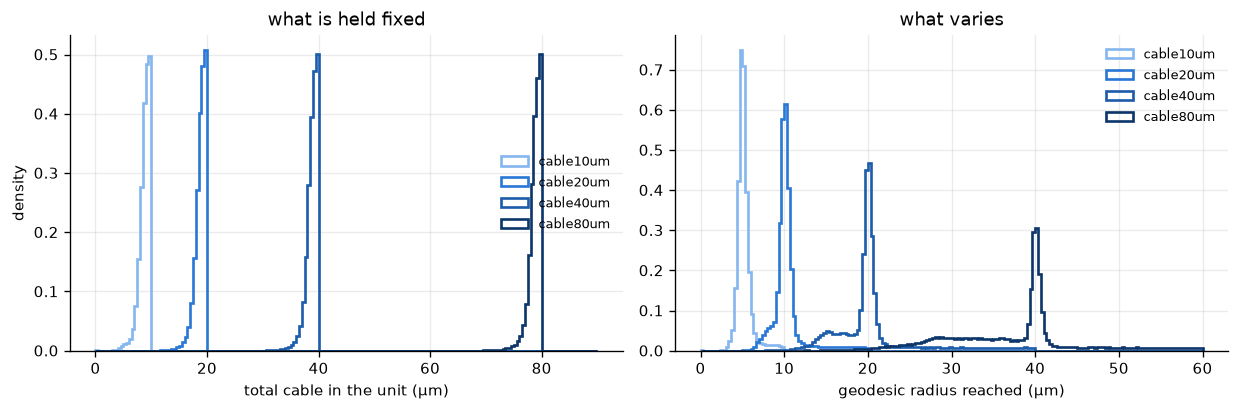

cable is pinned; radius is not
   cable10um  cable    9.0 µm (p10-p90   7.6-  9.8)   radius    5.0 µm (p10-p90   4.4-  6.0)
   cable20um  cable   19.0 µm (p10-p90  17.6- 19.8)   radius   10.1 µm (p10-p90   8.8- 11.4)
   cable40um  cable   39.0 µm (p10-p90  37.5- 39.8)   radius   20.0 µm (p10-p90  15.4- 26.0)
   cable80um  cable   79.0 µm (p10-p90  77.5- 79.8)   radius   39.7 µm (p10-p90  27.2- 59.1)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.5))
for c in CABLE:
    axes[0].hist(S[f"nb_{c}__sample_cable"] / 1000, bins=np.linspace(0, 90, 181),
                 histtype="step", lw=1.6, density=True, color=COLOR[c], label=c)
    axes[1].hist(S[f"nb_{c}__sample_radius"] / 1000, bins=np.linspace(0, 60, 181),
                 histtype="step", lw=1.6, density=True, color=COLOR[c], label=c)
axes[0].set_xlabel("total cable in the unit (µm)"); axes[0].set_title("what is held fixed")
axes[1].set_xlabel("geodesic radius reached (µm)"); axes[1].set_title("what varies")
axes[0].set_ylabel("density")
for ax in axes:
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print("cable is pinned; radius is not")
for c in CABLE:
    r = S[f"nb_{c}__sample_radius"] / 1000
    cb = S[f"nb_{c}__sample_cable"] / 1000
    print(f"  {c:>10}  cable {np.median(cb):6.1f} µm (p10-p90 "
          f"{np.percentile(cb,10):5.1f}-{np.percentile(cb,90):5.1f})   "
          f"radius {np.median(r):6.1f} µm (p10-p90 "
          f"{np.percentile(r,10):5.1f}-{np.percentile(r,90):5.1f})")

## 3. Matching a node budget to a cable budget

A neighbourhood of k nodes is a tree with k-1 edges, so it holds about 2(k-1) µm of
cable at ~2 µm spacing. The matched pairs are therefore `n10` <-> `cable20um`,
`n20` <-> `cable40um`, `n40` <-> `cable80um`.

Pairing by the same number instead (`n10` with `cable10um`) compares units that
differ about two-fold in how much skeleton they hold, which would confound any
model comparison built on it. Both pairings are printed so the gap is visible.

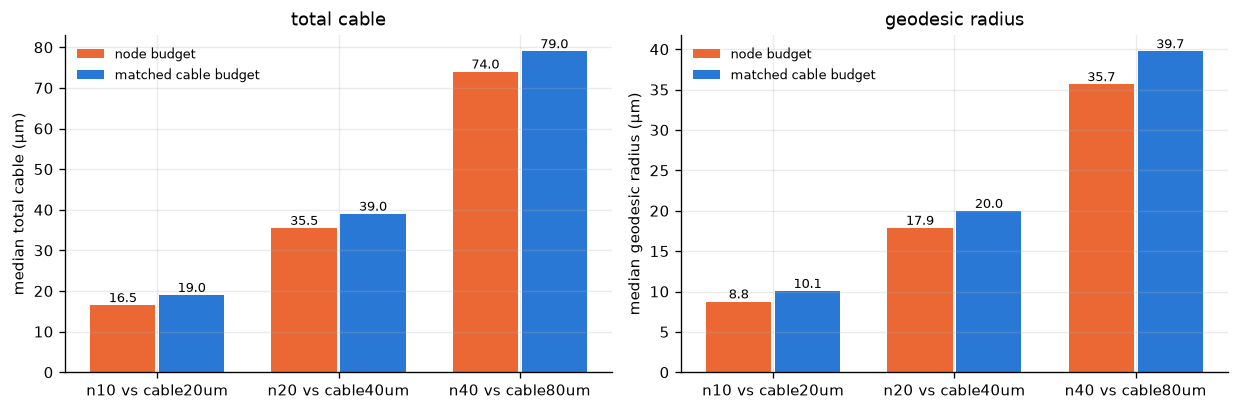

matched pairs, median cable
   n10   16.5 µm  vs   cable20um   19.0 µm   ratio 0.87x
   n20   35.5 µm  vs   cable40um   39.0 µm   ratio 0.91x
   n40   74.0 µm  vs   cable80um   79.0 µm   ratio 0.94x
the naive same-number pairing, for contrast (cable)
   n10   16.5 µm  vs   cable10um    9.0 µm   ratio 1.83x
   n20   35.5 µm  vs   cable20um   19.0 µm   ratio 1.87x
   n40   74.0 µm  vs   cable40um   39.0 µm   ratio 1.90x

matched pairs, median radius
   n10    8.8 µm  vs   cable20um   10.1 µm   ratio 0.87x
   n20   17.9 µm  vs   cable40um   20.0 µm   ratio 0.90x
   n40   35.7 µm  vs   cable80um   39.7 µm   ratio 0.90x
the naive same-number pairing, for contrast (radius)
   n10    8.8 µm  vs   cable10um    5.0 µm   ratio 1.74x
   n20   17.9 µm  vs   cable20um   10.1 µm   ratio 1.78x
   n40   35.7 µm  vs   cable40um   20.0 µm   ratio 1.79x



In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.5))
x = np.arange(len(NPAIRS))
for ax, (col, lab) in zip(axes, [("cable p50 (µm)", "total cable"),
                                 ("radius p50 (µm)", "geodesic radius")]):
    nd = [tbl.loc[n, col] for n, _ in NPAIRS]
    cb = [tbl.loc[u, col] for _, u in NPAIRS]
    ax.bar(x - 0.19, nd, 0.36, label="node budget", color="#eb6834")
    ax.bar(x + 0.19, cb, 0.36, label="matched cable budget", color="#2a78d6")
    for xi, (a, b) in enumerate(zip(nd, cb)):
        ax.text(xi - 0.19, a, f"{a:.1f}", ha="center", va="bottom", fontsize=8)
        ax.text(xi + 0.19, b, f"{b:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([f"{n} vs {u}" for n, u in NPAIRS])
    ax.set_ylabel(f"median {lab} (µm)"); ax.set_title(lab)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

for col, lab in [("cable p50 (µm)", "cable"), ("radius p50 (µm)", "radius")]:
    print(f"matched pairs, median {lab}")
    for n, u in NPAIRS:
        a, b = tbl.loc[n, col], tbl.loc[u, col]
        print(f"  {n:>4} {a:6.1f} µm  vs  {u:>10} {b:6.1f} µm   ratio {a/b:.2f}x")
    print(f"the naive same-number pairing, for contrast ({lab})")
    for n, u in zip(NNODE, CABLE[:3]):
        a, b = tbl.loc[n, col], tbl.loc[u, col]
        print(f"  {n:>4} {a:6.1f} µm  vs  {u:>10} {b:6.1f} µm   ratio {a/b:.2f}x")
    print()

## 4. ECDFs

No bin width and no density normalisation, so every config is directly comparable
on one axis. Two panels because the unit fixes one quantity and frees the other:

- **cable** — the four `cable*` configs rise almost vertically at their budgets;
  the three `n*` configs cross them and keep going, because a node budget does not
  cap cable.
- **radius** — nothing is vertical. Even a pinned cable budget spreads over a wide
  range of radii, and that spread *is* the local branching.

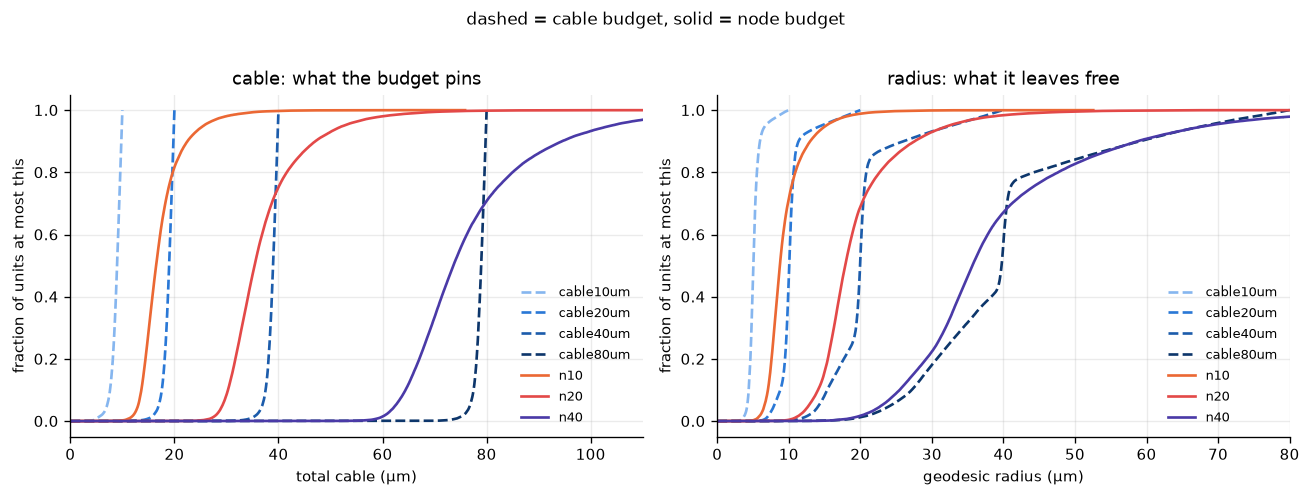

    config  cable p50  cable p90  radius p50  radius p90  radius p10-p90 spread  (µm)
 cable10um        9.0        9.8         5.0         6.0         4.4-6.0 (1.4x)
 cable20um       19.0       19.8        10.1        11.4        8.8-11.4 (1.3x)
 cable40um       39.0       39.8        20.0        26.0       15.4-26.0 (1.7x)
 cable80um       79.0       79.8        39.7        59.1       27.2-59.1 (2.2x)
       n10       16.5       22.5         8.8        13.0        7.1-13.0 (1.8x)
       n20       35.4       47.1        17.9        27.6       14.1-27.6 (2.0x)
       n40       73.6       94.5        35.7        58.8       25.5-58.8 (2.3x)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, lab, xmax in ((axes[0], "sample_cable", "total cable (µm)", 110),
                           (axes[1], "sample_radius", "geodesic radius (µm)", 80)):
    for c in NCONFIGS:
        v = np.sort(S[f"nb_{c}__{key}"] / 1000)
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), lw=1.6, color=COLOR[c],
                ls="--" if c.startswith("cable") else "-", label=c)
    ax.set_xlim(0, xmax); ax.set_xlabel(lab); ax.set_ylabel("fraction of units at most this")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
axes[0].set_title("cable: what the budget pins")
axes[1].set_title("radius: what it leaves free")
fig.suptitle("dashed = cable budget, solid = node budget", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

print(f"{'config':>10} {'cable p50':>10} {'cable p90':>10} "
      f"{'radius p50':>11} {'radius p90':>11} {'radius p10-p90 spread':>22}  (µm)")
for c in NCONFIGS:
    cb = S[f"nb_{c}__sample_cable"] / 1000
    rd = S[f"nb_{c}__sample_radius"] / 1000
    lo, hi = np.percentile(rd, 10), np.percentile(rd, 90)
    print(f"{c:>10} {np.median(cb):>10.1f} {np.percentile(cb,90):>10.1f} "
          f"{np.median(rd):>11.1f} {np.percentile(rd,90):>11.1f} "
          f"{f'{lo:.1f}-{hi:.1f} ({hi/max(lo,1e-9):.1f}x)':>22}")

## 5. How far does a fixed amount of cable actually reach?

The ratio radius / (cable/2) is 1.0 for a perfectly straight unbranched neurite
(cable spent equally in two directions) and falls toward 0 as the unit branches or
doubles back. It is a branching index that needs no extra data.

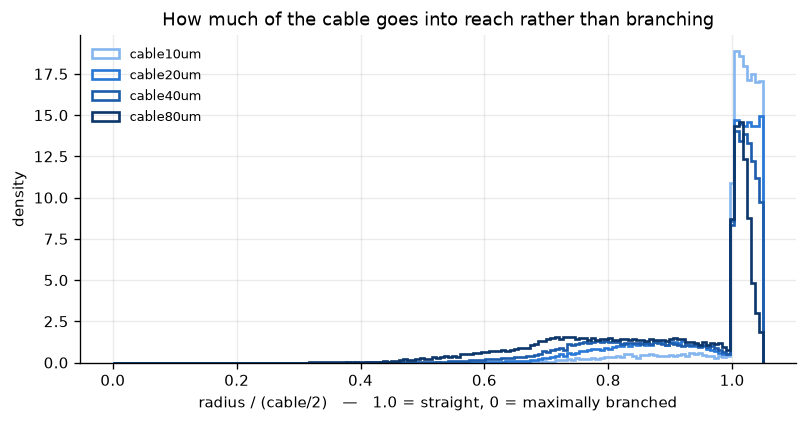

   cable10um  median 1.126   p10 1.017  p90 1.409
   cable20um  median 1.063   p10 0.950  p90 1.252


   cable40um  median 1.026   p10 0.794  p90 1.347
   cable80um  median 1.007   p10 0.690  p90 1.502


In [6]:
fig, ax = plt.subplots(figsize=(6.8, 3.6))
for c in CABLE:
    cb = S[f"nb_{c}__sample_cable"] / 1000
    rd = S[f"nb_{c}__sample_radius"] / 1000
    ok = cb > 0
    ax.hist(rd[ok] / (cb[ok] / 2), bins=np.linspace(0, 1.05, 160), histtype="step",
            lw=1.6, density=True, color=COLOR[c], label=c)
ax.set_xlabel("radius / (cable/2)   —   1.0 = straight, 0 = maximally branched")
ax.set_ylabel("density"); ax.legend(frameon=False, fontsize=8)
ax.set_title("How much of the cable goes into reach rather than branching")
plt.tight_layout(); plt.show()

for c in CABLE:
    cb = S[f"nb_{c}__sample_cable"] / 1000
    rd = S[f"nb_{c}__sample_radius"] / 1000
    ok = cb > 0
    q = rd[ok] / (cb[ok] / 2)
    print(f"  {c:>10}  median {np.median(q):.3f}   "
          f"p10 {np.percentile(q,10):.3f}  p90 {np.percentile(q,90):.3f}")

## 6. Per cell type

Cable is fixed by construction, so what varies by type is the **radius** that cable reaches — small where the arbor branches densely.

,cable10um,cable20um,cable40um,cable80um,n10,n20,n40,n cells
astrocyte,5.3,9.7,14.8,21.1,9.2,14.7,21.6,77
OPC,5.1,10.0,17.7,27.3,8.8,16.8,26.8,3
microglia,5.2,10.1,17.9,29.9,9.1,17.1,29.1,30
oligo,5.2,10.2,19.6,31.7,9.5,18.9,32.5,16
NMC,5.0,10.0,19.8,36.6,8.6,17.4,34.0,20
PV,5.1,10.0,19.8,36.6,8.7,17.5,34.2,174
MC,5.0,10.0,19.8,36.7,8.7,17.6,34.2,82
ITC,5.0,10.0,19.8,36.8,8.6,17.3,33.6,71
NGC,5.1,10.0,19.8,36.9,8.7,17.7,34.3,15
AltBasket,5.0,10.0,19.9,38.4,8.7,17.8,35.1,34


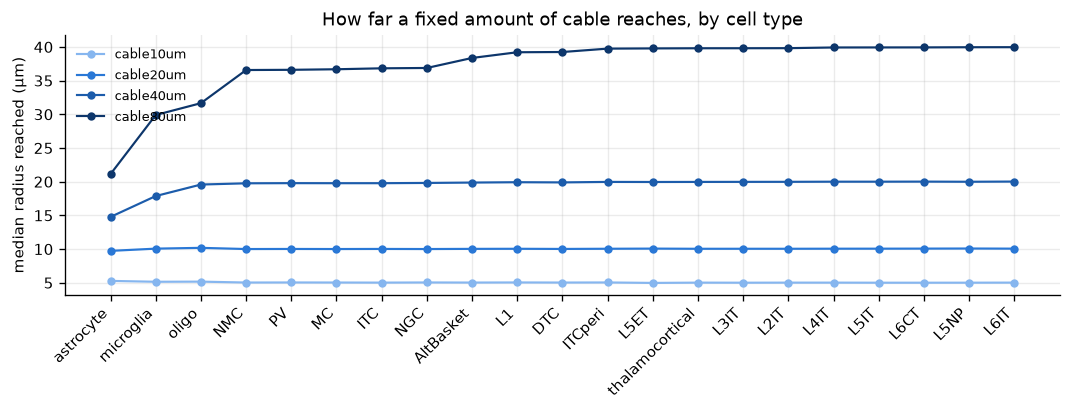

In [7]:
ct = {int(r): str(t) for r, t in zip(S["restrict_root_id"], S["restrict_cell_type"])}
rad = {}
for c in NCONFIGS:
    rid = S[f"nb_{c}__cell_root_id"]
    rad[c] = pd.Series(S[f"nb_{c}__cell_median_radius"] / 1000,
                       index=[ct.get(int(r), "?") for r in rid]).groupby(level=0).median()
by_type = pd.DataFrame(rad)
by_type["n cells"] = pd.Series(
    [ct.get(int(r), "?") for r in S["nb_cable40um__cell_root_id"]]).value_counts()
by_type = by_type.sort_values("cable80um")
display(by_type.style.format({**{c: "{:.1f}" for c in NCONFIGS}, "n cells": "{:.0f}"}))

fig, ax = plt.subplots(figsize=(9, 3.5))
sub = by_type[by_type["n cells"] >= 10]
xs = np.arange(len(sub))
for c in CABLE:
    ax.plot(xs, sub[c], "o-", ms=4, lw=1.3, color=COLOR[c], label=c)
ax.set_xticks(xs); ax.set_xticklabels(sub.index, rotation=45, ha="right")
ax.set_ylabel("median radius reached (µm)")
ax.set_title("How far a fixed amount of cable reaches, by cell type")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 7. Reading one neighbourhood, and joining embeddings

`members` indexes the restricted node array, centre first. `cache_index` maps to
the row in `graph_cache/<root_id>.pt`; `orig_node_ids` is the CAVE skeleton vertex
id.

In [8]:
import torch

rid = int(S["nb_cable40um__cell_root_id"][0])
N = np.load(DB_ROOT / "neighborhoods" / "cable40um" / f"{rid}.npz")
d = torch.load(REPO_ROOT / "data" / "graph_cache" / f"{rid}.pt", weights_only=False)

off, mem = N["offsets"], N["members"]
k = int(np.argmax(N["n_members"]))
m = mem[off[k]:off[k + 1]]
emb = d.x.numpy()[N["cache_index"][m]]
print(f"cell {rid}: {len(off)-1:,} neighbourhoods")
print(f"unit {k}: centre = restricted node {m[0]}, {len(m)} members")
print(f"  total cable {N['cable_nm'][k]:,.0f} nm, radius {N['radius_nm'][k]:,.0f} nm")
print(f"  CAVE vertex ids: {N['orig_node_ids'][m][:6]} ...")
print(f"  embedding set: {emb.shape}")

/home/jcbliao/rotation/segclr/gnn_classifier/segclr_db/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cell 864691134800773453: 346 neighbourhoods
unit 19: centre = restricted node 19, 27 members
  total cable 39,149 nm, radius 17,930 nm
  CAVE vertex ids: [19 20 15 30 38 16] ...
  embedding set: (27, 64)


## What to take from this

- **Cable is pinned, radius is not.** That is the whole point of the unit: every
  unit holds the same amount of skeleton, and how far it reaches is a measured
  property of the local branching rather than an input. The radius ECDF in section
  4 is the one to look at — it is the only quantity here the budget does not fix.
- **radius / (cable/2) is a free branching index.** 1.0 means the cable went
  entirely into reach (a straight unbranched neurite); lower means it went into
  branches. It needs no data beyond what is already stored.
- **A node budget is close to a cable budget** at these sizes, because spacing is
  near-uniform — `n10`/`n20`/`n40` land within a few percent of
  `cable20um`/`cable40um`/`cable80um`. Where they diverge is where spacing is
  irregular.
- **Do not read a `neighborhoods/` config name as a `paths/` one.** `cable20um` is
  20 µm of cable; `paths/20um` is a 20 µm diameter route.